<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/DailyChallenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('/content/sample_data/california_housing_train.csv')
    print("Dataset chargé avec succès.")

    df_clean = df.copy()


    scaler = MinMaxScaler()
    column_to_scale = "median_house_value"

    df_clean["value_normalized"] = scaler.fit_transform(df_clean[[column_to_scale]])

    print(f"Normalisation de {column_to_scale} terminée.")
    display(df_clean[[column_to_scale, "value_normalized"]].head())

except Exception as e:
    print(f"Erreur : {e}")

Dataset chargé avec succès.
Normalisation de median_house_value terminée.


,median_house_value,value_normalized
0,66900.0,0.107012
1,80100.0,0.134228
2,85700.0,0.145775
3,73400.0,0.120414
4,65500.0,0.104125


In [28]:
import os
from sklearn.preprocessing import MinMaxScaler

try:
    print("Valeurs manquantes par colonne :")
    print(df.isnull().sum())

    df_clean = df.copy()
    print("\nCopie df_clean créée avec succès.")

    scaler = MinMaxScaler()
    column_name = "median_house_value"

    if column_name in df_clean.columns:
        df_clean["value_normalized"] = scaler.fit_transform(df_clean[[column_name]])
        print(f"Normalisation de {column_name} effectuée.")
        display(df_clean[[column_name, "value_normalized"]].head())
    else:
        print(f"Erreur : La colonne '{column_name}' est introuvable dans le dataset.")

except NameError:
    print("Erreur : La variable 'df' n'existe pas. Veuillez exécuter la cellule de chargement (hxf43NL4mM78) d'abord.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")


Valeurs manquantes par colonne :
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Copie df_clean créée avec succès.
Normalisation de median_house_value effectuée.


,median_house_value,value_normalized
0,66900.0,0.107012
1,80100.0,0.134228
2,85700.0,0.145775
3,73400.0,0.120414
4,65500.0,0.104125


In [34]:
import numpy as np
from sklearn.decomposition import PCA

numeric_df = df_clean.select_dtypes(include=[np.number])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_df)

df_clean["PCA1"] = pca_result[:, 0]
df_clean["PCA2"] = pca_result[:, 1]

print("Ratio de variance expliquée :", pca.explained_variance_ratio_)

housing_stats = df_clean.groupby("housing_median_age")["median_house_value"].agg(
    prix_moyen="mean",
    prix_median="median",
    nombre_maisons="count"
)

display(housing_stats.head())


Ratio de variance expliquée : [9.99549198e-01 4.47163098e-04]


,prix_moyen,prix_median,nombre_maisons
housing_median_age,,,
1.0,190250.000000,190250.0,2
2.0,229438.836735,191700.0,49
3.0,239450.043478,216400.0,46
4.0,230054.105590,198900.0,161
5.0,211035.708543,176900.0,199


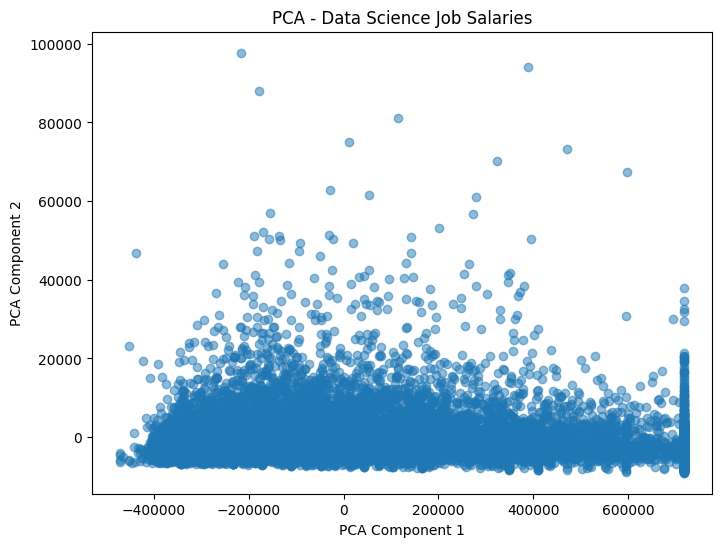

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(df_clean["PCA1"], df_clean["PCA2"], alpha=0.5)
plt.title("PCA - Data Science Job Salaries")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()